# Olist Sales and Reviews Analysis
## Exploratory Data Analysis (EDA)
This notebook provides a comprehensive analysis of the Olist E-commerce dataset. The goal is to uncover patterns in sales performance, regional distribution, and customer satisfaction across different product categories.

### Objectives:
1.  **[Establish Connection](#Establish-Connection)**: Set up the SQL Server connection via `pyodbc`.
2.  **[Reading Tables](#Reading-Tables-from-Gold-Schema)**: Importing processed data from the 'Gold' schema.
3.  **[Sales Distribution by State and Category](#Sales-Distribution-by-State-and-Category)**: Identifying top regions and categories using interactive Treemaps.
4.  **[Sales Heatmap](#Sales-Heatmap-by-Product-Category-and-State)**: Visualizing market density and product-state correlations.
5. **[Customer Ratings Analysis](#Top-15-Categories-by-Average-Customer-Rating)**: Evaluation of product quality and customer satisfaction.
6. **[Product Categories by Total Sales](#Top-10-Product-Categories-by-Total-Sales)**: Identifying market leaders. 
7. **[Regional Sales Performance](#Regional-Sales-Performance)**: A geographical breakdown of sales across different states. 
8. **[Basic Business KPIs](#Basic-Business-KPIs-(Key-Performance-Indicators))**: A high-level summary of the business health.
---

In [1]:
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

### Establish Connection

In [2]:
cnxn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={r'localhost\SQLEXPRESS'};"
    f"DATABASE={'ecommerceDWH'};"
    "Trusted_Connection=yes;")

In [3]:
gold_tables = pd.read_sql_query("""
SELECT TABLE_NAME
FROM INFORMATION_SCHEMA.TABLES
WHERE TABLE_SCHEMA = 'gold'
ORDER BY TABLE_NAME
""", cnxn)

In [4]:
gold_tables

,TABLE_NAME
0,maven_daily_orders_revenue
1,maven_marketing_funnel
2,maven_products_performance
3,olist_dim_customers
4,olist_dim_products
5,olist_dim_sellers
6,olist_fact_sales


### Reading Tables from Gold Schema

In [5]:
customers = pd.read_sql("SELECT * FROM gold.olist_dim_customers;", cnxn)
products = pd.read_sql("SELECT * FROM gold.olist_dim_products;", cnxn)
sellers = pd.read_sql("SELECT * FROM gold.olist_dim_sellers;", cnxn)
sales = pd.read_sql("SELECT * FROM gold.olist_fact_sales;", cnxn)

In [6]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,"""2a4e10a332748a0ce92f8189c2ca4a1c""",f0eff4d455cf4f8011510095cb94d553,05003,sao paulo,SP\r
1,"""2a4f46deb28e6867b88c553c355ea34a""","""121c07493c505cd381f53240c2161f73""",55750,surubim,PE\r
2,"""2a5050a15ba0fe3b15ce7e7add83e818""",a410c0f1153135827374d41b1727ef40,04635,sao paulo,SP\r
3,"""2a50e9151ecf1b477d053cc68820a5a4""",cf56ccfd32ac8a510501a6fa69972c74,26221,nova iguacu,RJ\r
4,"""2a5161ad7eaa9de4de0eea62824a56a3""",bf582deaa74aed9e0918f2aecd8fa959,43820,candeias,BA\r


In [7]:
products.head()

,product_id,product_category
0,"""00066f42aeeb9f3007548bb9d3f33c38""",perfumery\r
1,"""00088930e925c41fd95ebfe695fd2655""",auto\r
2,"""0009406fd7479715e4bef61dd91f2462""",bed_bath_table\r
3,"""000b8f95fcb9e0096488278317764d19""",housewares\r
4,"""000d9be29b5207b54e86aa1b1ac54872""",watches_gifts\r


In [8]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,"""0015a82c2db000af6aaaf3ae2ecb0532""",09080,santo andre,SP\r
1,"""001cca7ae9ae17fb1caed9dfb1094831""",29156,cariacica,ES\r
2,"""001e6ad469a905060d959994f1b41e4f""",24754,sao goncalo,RJ\r
3,"""002100f778ceb8431b7a1020ff7ab48f""",14405,franca,SP\r
4,"""003554e2dce176b5555353e4f3555ac8""",74565,goiania,GO\r


In [9]:
sales.head()

,order_id,order_item_id,order_date,customer_id,product_id,seller_id,product_category,customer_state,seller_state,order_status,review_score,payments,installments,price,freight_value,total_item_value,total_payment_value
0,"""00010242fe8c5a6d1ba2dd792cb16214""",1,2017-09-13,"""3ce436f183e68e07877b285a838db11a""","""4244733e06e7ecb4970a6e2683c13e61""","""48436dade18ac8b2bce089ec2a041202""",cool_stuff\r,RJ\r,SP\r,delivered,5.0,credit_card,2,58.90,None,None,0.0
1,"""00018f77f2f0320c557190d7a144bdd3""",1,2017-04-26,f6dd3ec061db4e3987629fe6b26e5cce,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,pet_shop\r,SP\r,SP\r,delivered,4.0,credit_card,3,239.90,None,None,0.0
2,"""000229ec398224ef6ca0657da4fc703e""",1,2018-01-14,"""6489ae5e4333f3693df5ad4372dab6d3""",c777355d18b72b67abbeef9df44fd0fd,"""5b51032eddd242adc84c38acab88f23d""",furniture_decor\r,MG\r,MG\r,delivered,5.0,credit_card,5,199.00,None,None,0.0
3,"""00024acbcdf0a6daa1e931b038114c75""",1,2018-08-08,d4eb9395c8c0431ee92fce09860c5a06,"""7634da152a4610f1595efa32f14722fc""","""9d7a1d34a5052409006425275ba1c2b4""",perfumery\r,SP\r,SP\r,delivered,4.0,credit_card,2,12.99,None,None,0.0
4,"""00042b26cf59d7ce69dfabb4e55b4fd9""",1,2017-02-04,"""58dbd0b2d70206bf40e62cd34e84d795""",ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,garden_tools\r,SP\r,PR\r,delivered,5.0,credit_card,3,199.90,None,None,0.0


### Sales Distribution by State and Category

In [10]:
# 1. Data Cleaning:
# Strip hidden characters (like \r) and whitespace from names 
# to ensure the Treemap labels are clean and properly grouped.
sales['product_category'] = sales['product_category'].str.strip()
sales['customer_state'] = sales['customer_state'].str.strip()

# 2. Aggregation:
# Grouping data by State and then by Product Category.
# We calculate total revenue (using 'price') and unique order counts.
sales_by_cat_state = (
    sales 
    .groupby(['product_category', 'customer_state'], as_index=False)
    .agg(
        total_sales=('price', 'sum'),
        total_orders=('order_id', 'nunique')
    )
)

# 3. Treemap Configuration:
# path: Defines the hierarchy (Customer State -> Product Category).
# values: Determines the size of each box based on revenue.
# color: Uses color intensity to represent sales performance.
fig = px.treemap(
    sales_by_cat_state,
    path=['customer_state', 'product_category'], 
    values='total_sales',
    color='total_sales',
    color_continuous_scale='Viridis',
    title='Interactive Sales Distribution by State and Product Category'
)

# 4. Layout Optimization:
# Adjusting margins to ensure the title and chart components are perfectly centered.
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))

# 5. Display:
fig.show()

### Sales Heatmap by Product Category and State

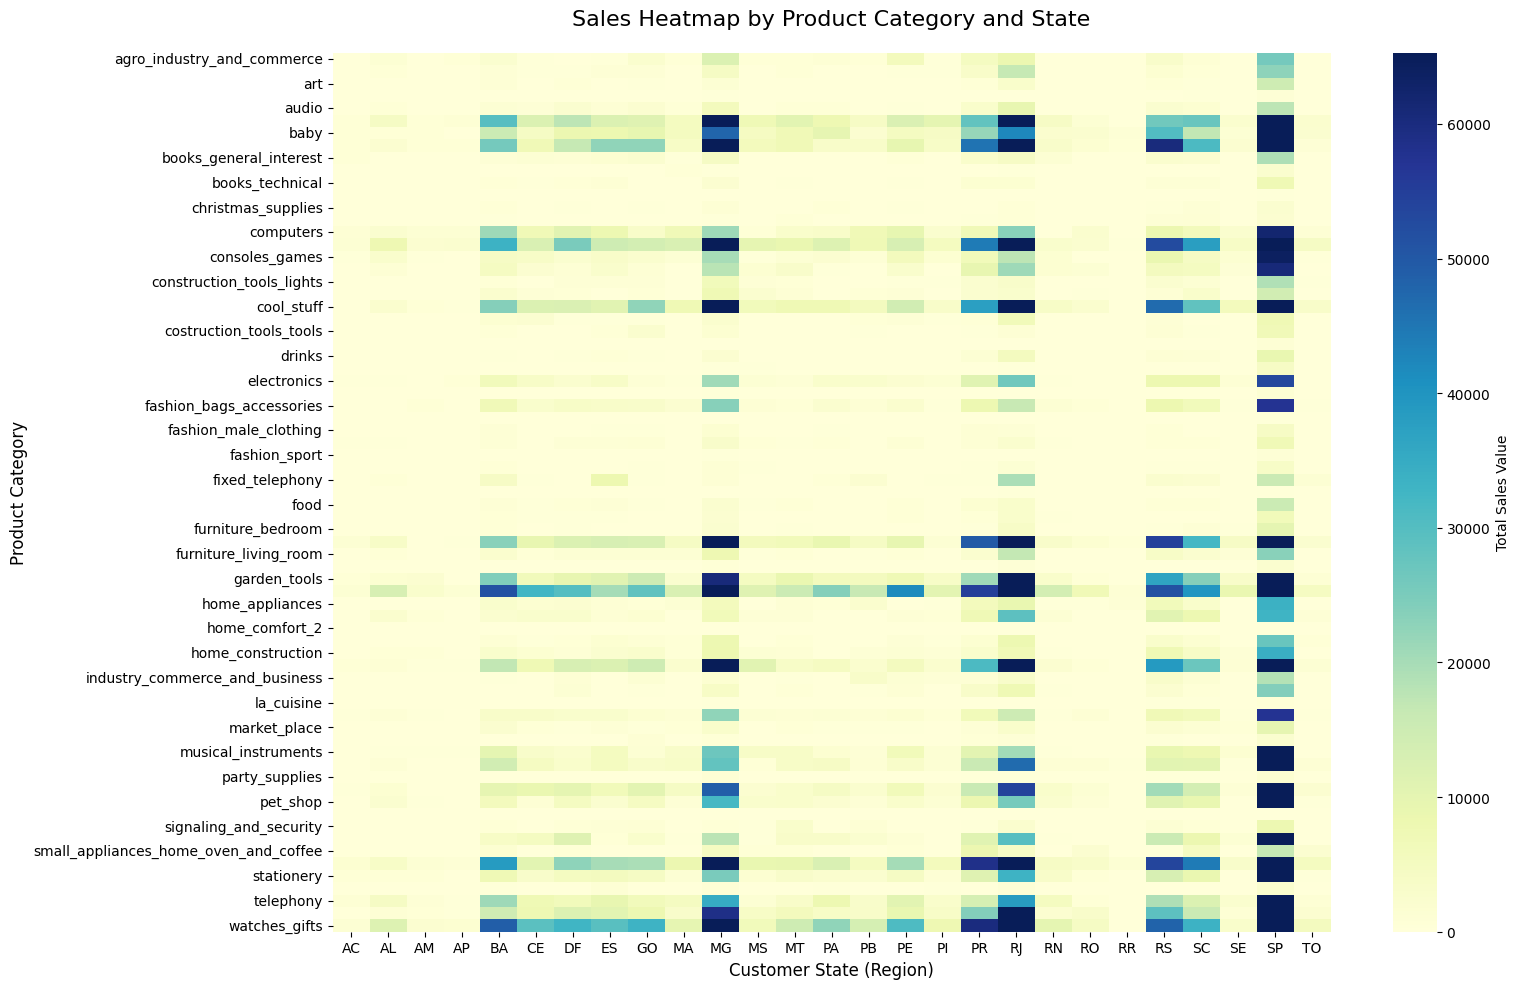

In [11]:
# 1. Data Reshaping:
# Create a pivot table where rows are product categories and columns are states.
# fillna(0) ensures that missing sales combinations appear as zero rather than blank spots.
pivot_sales = sales_by_cat_state.pivot(
    index='product_category', 
    columns='customer_state', 
    values='total_sales'
).fillna(0) 

# 2. Plotting the Heatmap:
plt.figure(figsize=(16, 10))
sns.heatmap(
    pivot_sales, 
    cmap='YlGnBu',      # Sequential color scale (Yellow to Green to Blue)
    robust=True,        # Minimizes the influence of extreme outliers on the color scale
    cbar_kws={'label': 'Total Sales Value'} # Adds a label to the color bar
)

# 3. Styling and Annotation:
# Adding descriptive titles and labels for a clear presentation.
plt.title('Sales Heatmap by Product Category and State', fontsize=16, pad=20)
plt.xlabel('Customer State (Region)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

# 4. Final Display:
# Automatically adjust subplot parameters to give specified padding.
plt.tight_layout()
plt.show()

### Top 15 Categories by Average Customer Rating 

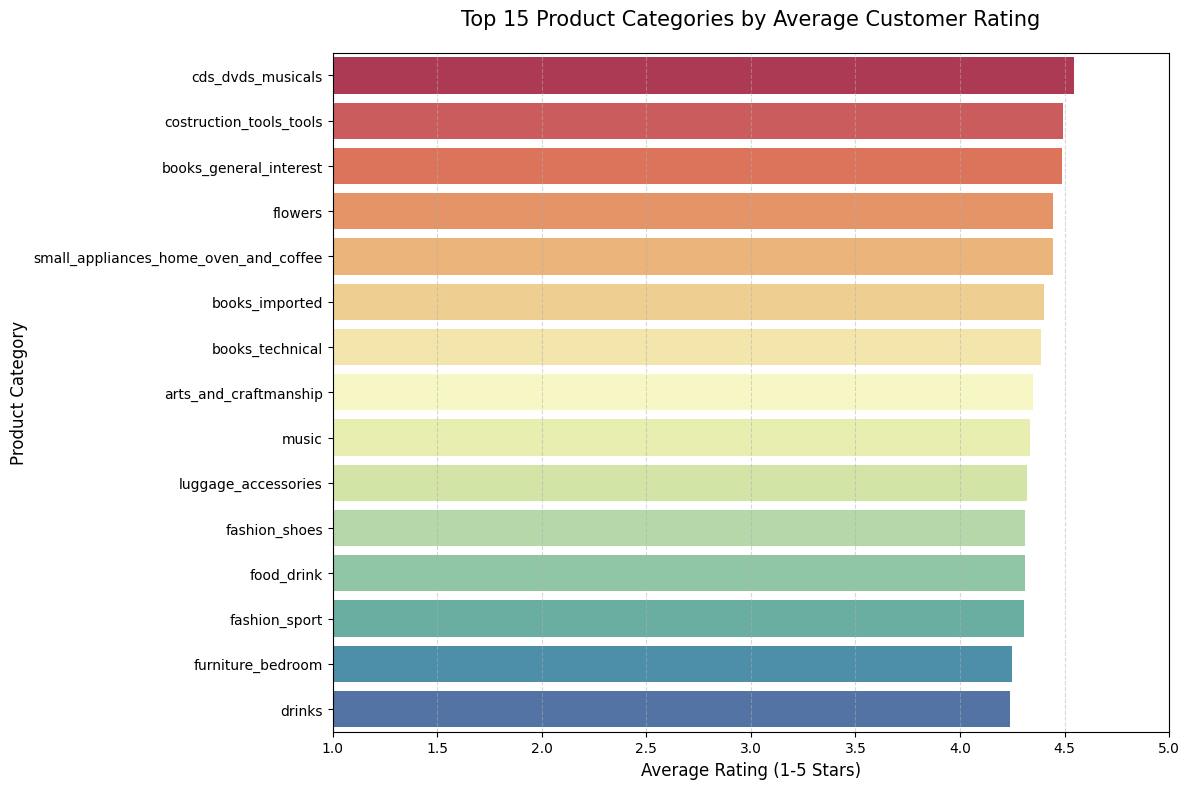

In [12]:
# 1. Aggregating data
review_by_category = (
    sales.groupby('product_category', as_index=False)
    .agg(avg_review=('review_score', 'mean'))
    .sort_values(by='avg_review', ascending=False)
)

# 2. Plotting with updated parameters to avoid FutureWarning
plt.figure(figsize=(12, 8))
sns.barplot(
    data=review_by_category.head(15), 
    x='avg_review', 
    y='product_category', 
    hue='product_category',  # Assign y variable to hue
    palette='Spectral',      # Now palette works correctly with hue
    legend=False             # Disable legend to keep the chart clean
)

# 3. Final touches
plt.xlim(1, 5)
plt.title('Top 15 Product Categories by Average Customer Rating', fontsize=15, pad=20)
plt.xlabel('Average Rating (1-5 Stars)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Top 10 Product Categories by Total Sales

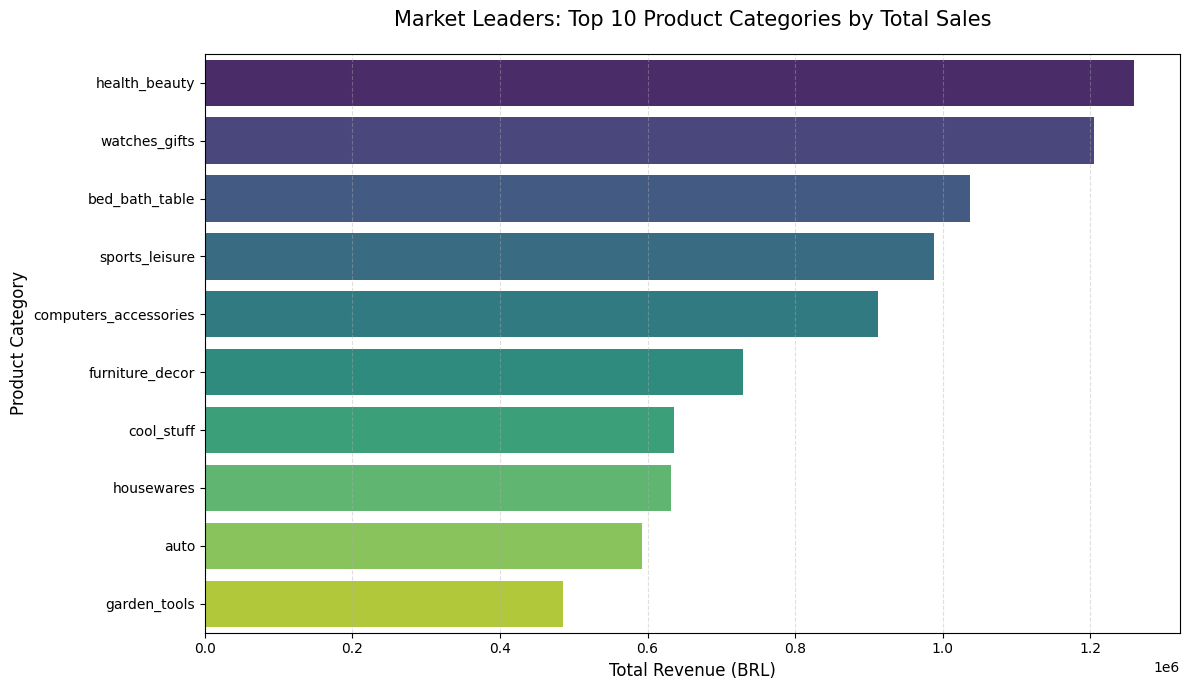

In [13]:
# 1. Aggregation:
# Grouping by category and summing the 'price' column.
# Note: Using 'price' instead of 'total_value' as it is the more reliable 
# metric for revenue in this dataset.
top_categories = (
    sales.groupby('product_category', as_index=False)
    .agg(total_sales=('price', 'sum'))
    .sort_values(by='total_sales', ascending=False)
    .head(10)
)

# 2. Visualization:
plt.figure(figsize=(12, 7))

# Using 'hue' and 'legend=False' to comply with the latest Seaborn 
# requirements and avoid the palette warning.
sns.barplot(
    data=top_categories,
    x='total_sales',
    y='product_category',
    hue='product_category', # Mapping categories to hue for colored bars
    palette='viridis',      # High-contrast color palette
    legend=False            # Removing redundant legend
)

# 3. Refinement:
# Adding professional labels and a descriptive title.
plt.title('Market Leaders: Top 10 Product Categories by Total Sales', fontsize=15, pad=20)
plt.xlabel('Total Revenue (BRL)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4) # Adding grid for better readability

plt.tight_layout()
plt.show()

### Regional Sales Performance

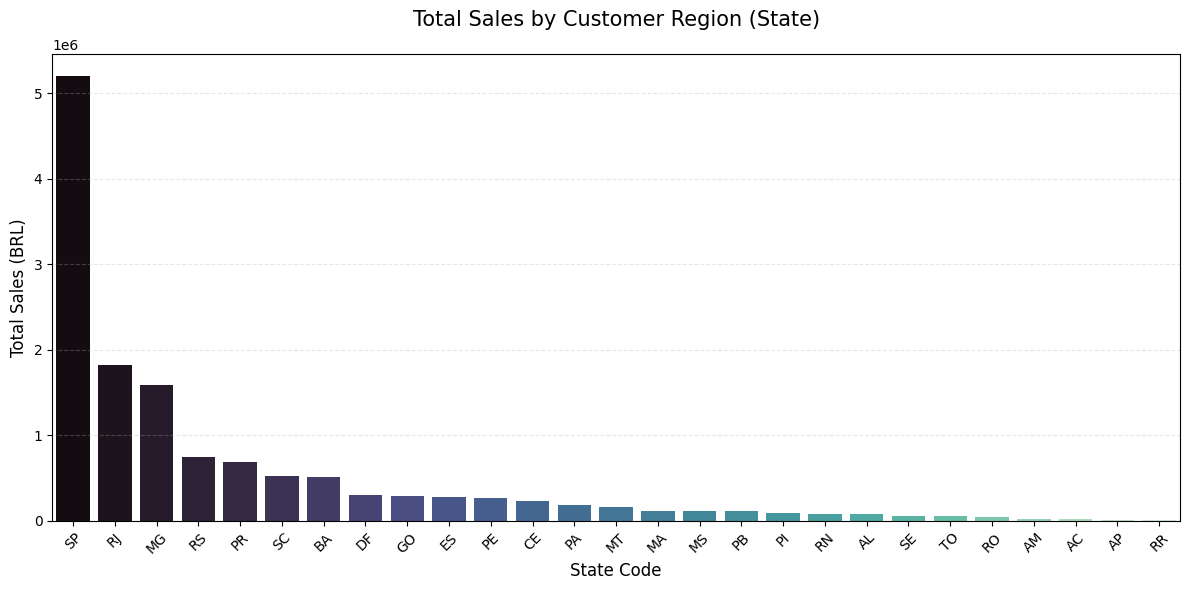

In [14]:
# 1. Aggregation:
# Grouping by state and calculating total sales from the 'price' column.
sales_by_region = (
    sales.groupby('customer_state', as_index=False)
    .agg(total_sales=('price', 'sum')) 
    .sort_values(by='total_sales', ascending=False)
)

# 2. Visualization:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=sales_by_region,
    x='customer_state',
    y='total_sales',
    hue='customer_state', 
    palette='mako',
    legend=False           
)

# 3. Refinement:
# Adding professional formatting and English labels.
plt.title('Total Sales by Customer Region (State)', fontsize=15, pad=20)
plt.xlabel('State Code', fontsize=12)
plt.ylabel('Total Sales (BRL)', fontsize=12)
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Basic Business KPIs (Key Performance Indicators)

In [15]:
# 1. Data Cleaning & Preparation:
# We ensure the columns used for financial metrics have no Null values to avoid calculation errors.
# We use the 'sales' dataframe as it contains the most comprehensive joined data.
sales['price'] = sales['price'].fillna(0)
sales['review_score'] = sales['review_score'].fillna(0)

# 2. Key Metric Calculations:

# Total Sales: Aggregating the sum of item prices to represent total gross revenue.
total_sales = sales['price'].sum()

# Total Orders: Calculating the count of unique order IDs to get the actual number of transactions.
total_orders = sales['order_id'].nunique()

# Customer Reach: Counting unique customer IDs to identify the size of our active customer base.
total_customers = sales['customer_id'].nunique()

# Average Order Value (AOV): Measuring the average revenue generated per unique order.
# A safety check is included to prevent "Division by Zero" errors.
avg_order_value = total_sales / total_orders if total_orders > 0 else 0

# Customer Satisfaction Index: Calculating the mean score of all customer reviews.
avg_review_score = sales['review_score'].mean()

# 3. Formatted Professional Output:
# Displaying the KPIs with clear formatting, currency symbols (R$ for BRL), and thousands separators.
print("====================================================")
print("            E-COMMERCE BUSINESS SUMMARY             ")
print("====================================================")
print(f"Total Sales Revenue     : R$ {total_sales:,.2f}")
print(f"Total Unique Orders     : {total_orders:,}")
print(f"Unique Customers        : {total_customers:,}")
print(f"Avg Order Value (AOV)   : R$ {avg_order_value:,.2f}")
print(f"Avg Customer Rating     : {avg_review_score:.2f} / 5.0")
print("====================================================")

            E-COMMERCE BUSINESS SUMMARY             
Total Sales Revenue     : R$ 13,591,643.70
Total Unique Orders     : 98,666
Unique Customers        : 98,666
Avg Order Value (AOV)   : R$ 137.75
Avg Customer Rating     : 2.46 / 5.0
